In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import zipfile

with zipfile.ZipFile('/content/AB_NYC_2019.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

df = pd.read_csv("/content/AB_NYC_2019.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load the dataset (assuming AB_NYC_2019.csv is already extracted)
df = pd.read_csv("/content/AB_NYC_2019.csv")

# 2. Handle missing values
# Fill NaN values in 'reviews_per_month' with 0
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 3. Feature Engineering: One-hot encode categorical columns
# 'neighbourhood_group', 'room_type', 'number_of_reviews' are good candidates for one-hot encoding
df_encoded = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type', 'number_of_reviews'], drop_first=True)

# 4. Define target variable (y) and features (x)
# Target variable is 'price'
y = df_encoded['price']

# Define columns to explicitly drop from features (non-numeric that were not one-hot encoded or are identifiers)
# 'name', 'host_name', 'neighbourhood', 'last_review' are non-numeric and not useful for linear regression.
# 'price' is the target variable and should not be in features.
columns_to_drop = ['name', 'host_name', 'neighbourhood', 'last_review', 'price']

# Create feature set x by dropping these columns
x = df_encoded.drop(columns=columns_to_drop, axis=1)

# 5. Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Data preparation complete!")
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data preparation complete!
Shape of x_train: (39116, 407)
Shape of x_test: (9779, 407)
Shape of y_train: (39116,)
Shape of y_test: (9779,)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [ ]:
df_encoded = pd.get_dummies(df, columns=['neighbourhood_group', 'room_type','number_of_reviews'], drop_first=True)

In [ ]:
df_encoded.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,last_review,...,number_of_reviews_480,number_of_reviews_488,number_of_reviews_510,number_of_reviews_540,number_of_reviews_543,number_of_reviews_576,number_of_reviews_594,number_of_reviews_597,number_of_reviews_607,number_of_reviews_629
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,149,1,2018-10-19,...,False,False,False,False,False,False,False,False,False,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,225,1,2019-05-21,...,False,False,False,False,False,False,False,False,False,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,150,3,NaN,...,False,False,False,False,False,False,False,False,False,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,89,1,2019-07-05,...,False,False,False,False,False,False,False,False,False,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,80,10,2018-11-19,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_encoded['reviews_per_month'] = df_encoded['reviews_per_month'].fillna(0)
# Removed the problematic conversion that truncated latitude and longitude
# cols_to_convert = df_encoded.select_dtypes(exclude=['object']).columns
# df_encoded[cols_to_convert] = df_encoded[cols_to_convert].astype(int)
df_encoded.head()

,id,name,host_id,host_name,neighbourhood,latitude,longitude,price,minimum_nights,last_review,...,number_of_reviews_480,number_of_reviews_488,number_of_reviews_510,number_of_reviews_540,number_of_reviews_543,number_of_reviews_576,number_of_reviews_594,number_of_reviews_597,number_of_reviews_607,number_of_reviews_629
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,149,1,2018-10-19,...,False,False,False,False,False,False,False,False,False,False
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,225,1,2019-05-21,...,False,False,False,False,False,False,False,False,False,False
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,150,3,NaN,...,False,False,False,False,False,False,False,False,False,False
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Clinton Hill,40.68514,-73.95976,89,1,2019-07-05,...,False,False,False,False,False,False,False,False,False,False
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,East Harlem,40.79851,-73.94399,80,10,2018-11-19,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
y = df_encoded['price']

# Define columns to explicitly drop (non-numeric that were not one-hot encoded)
columns_to_drop = ['name', 'host_name', 'neighbourhood', 'last_review', 'price']

# Create feature set x by dropping these columns
x = df_encoded.drop(columns=columns_to_drop, axis=1)


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Make predictions on the training and test sets
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"Training Mean Squared Error: {mse_train:.2f}")
print(f"Training R-squared: {r2_train:.2f}")
print(f"Test Mean Squared Error: {mse_test:.2f}")
print(f"Test R-squared: {r2_test:.2f}")

Training Mean Squared Error: 54830.57
Training R-squared: 0.10
Test Mean Squared Error: 38783.37
Test R-squared: 0.12


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Task 6.1: Import, initialize, and fit a standard Linear Regression model
# (x_train, y_train are already prepared from previous steps)
model = LinearRegression()
model.fit(x_train, y_train)
print("Model trained successfully.\n")

# Task 6.2: Use the trained model to generate price predictions on the testing data
y_test_pred = model.predict(x_test)
print("Predictions on test data generated.\n")

# Task 6.3: Calculate key evaluation metrics

# R-Squared (R2) Score
r2 = r2_score(y_test, y_test_pred)
print(f"R-Squared (R2) Score: {r2:.4f}")

# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_test_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model trained successfully.

Predictions on test data generated.

R-Squared (R2) Score: 0.1233
Mean Absolute Error (MAE): 71.25
Mean Squared Error (MSE): 38783.37
Root Mean Squared Error (RMSE): 196.93


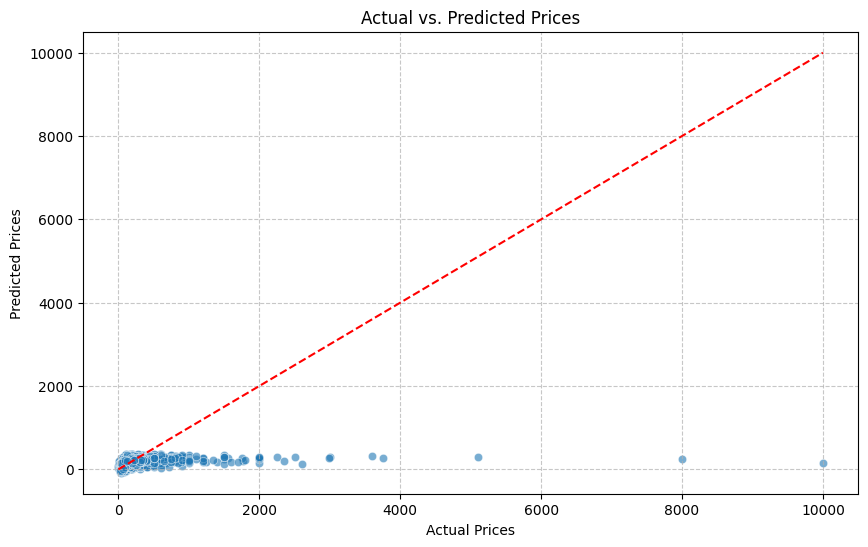

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 7.1: Scatter plot of Actual Prices vs. Predicted Prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # 45-degree line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

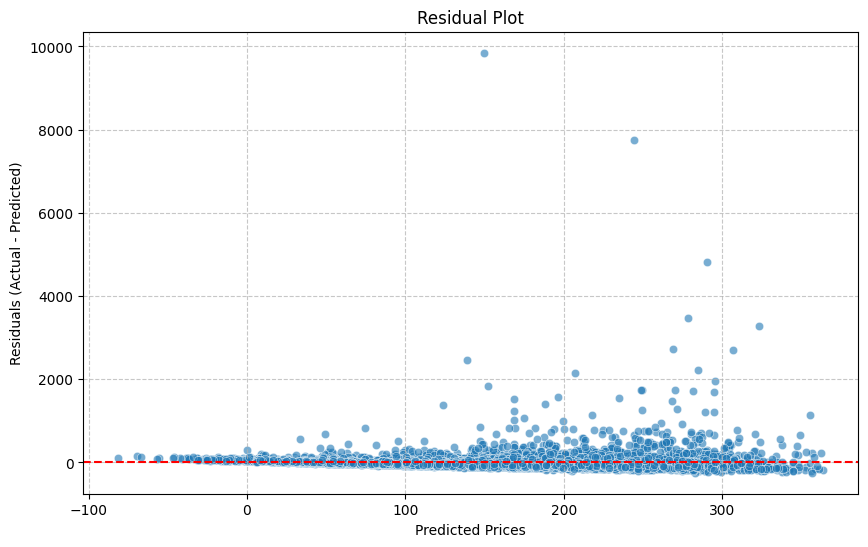

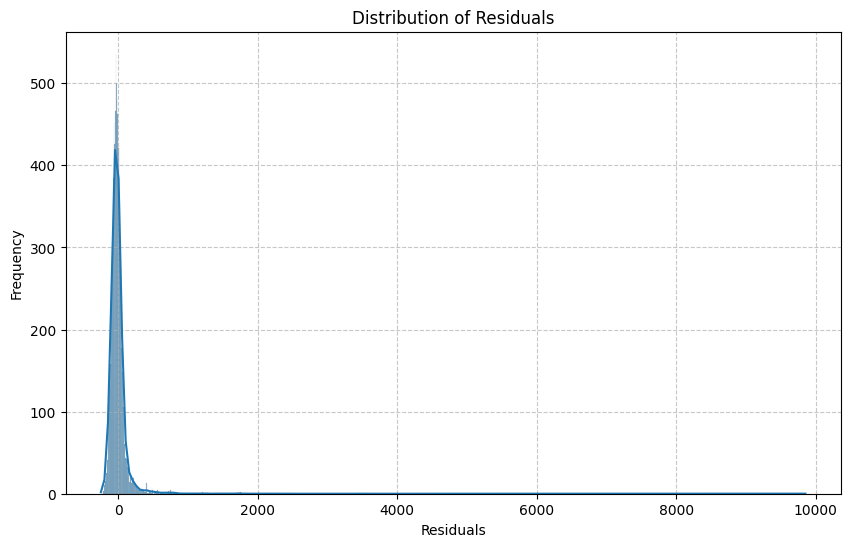

In [ ]:
# Task 7.2: Residual Plot (Errors vs. Predicted values)
residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # Horizontal line at y=0
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Optional: Histogram of Residuals
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()